# Imports

## General Imports

In [ ]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
from importlib import reload

import numba
import numpy as np
print('Numba 0.54.1 is known to work well with this package.')
print('Numba version that was imported:',numba.__version__)
print('Numpy 1.20.3 is known to work well with this package.')
print('Numpy version that was imported:',np.__version__)

## Specialized imports

In [ ]:
from common.baseclasses import AWA # https://github.com/asmcleod/common.git
from common.misc import flatten
from common import numerical_recipes as numrec

# It is known that `sympy` wraps `numpy` universal functions in a way that conflicts with `numba`.  Avoid importing `Materials` until necessary.
from NearFieldOptics import Materials as M # https://github.com/asmcleod/NearFieldOptics.git
from NearFieldOptics.Materials import material_types,TransferMatrixMedia

## EigenProbe imports

In [ ]:
import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

# Load probe and spectroscopies

In [2]:
a_nm=20
a=a_nm*1e-7 #in cm
L=24e-4 #probe length in cm, assuming cantilever thickness 4e-4 #Arrow probe: https://www.nanoworld.com/tapping-mode-reflex-coated-afm-tip-arrow-ncr
L_microns=L*1e4
taper_angle=21
geometry='hyperboloid'

Nnodes=244*2

#probe_name = '%s_a=%inm_taper=%i_L=%imicrons_Nnodes=%i'%(geometry.capitalize(),a_nm,taper_angle,L_microns,Nnodes)
#probe_name='hyperboloid'
#probe_name = 'Cone_a=20nm_taper=21_L=23microns_Nnodes=488'
probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244'
P = EP.load(probe_name,EP.Probe)
a = P.get_a()

ProbeGapSpectroscopy = EP.load(P, PS.ProbeGapSpectroscopyParallel, overwrite_probe=True)

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	Registering probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeGapSpectroscopy.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	Overwriting registered probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperbo

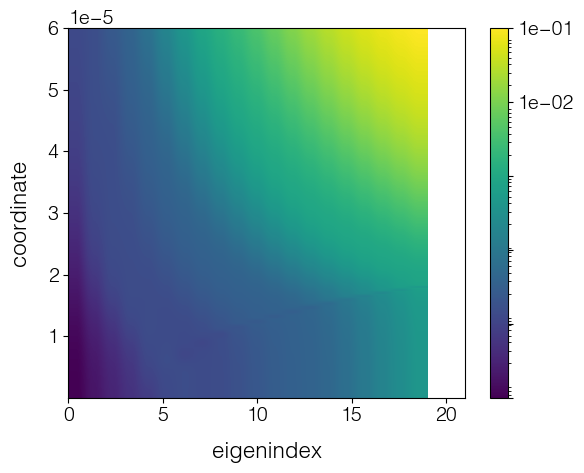

In [3]:
vs = ProbeGapSpectroscopy.get_eigenbrightness_AWA()
np.abs(vs).plot(log_scale=True)
Nmodes_compute = 20
plt.axvline(Nmodes_compute,color='w',ls='--')

#  Parameters of simulations

In [4]:
a_nm = 20
A_nm = 2*a_nm
gapmin_nm = a_nm/10
kappa_max=20/P.get_a()
Nkappas = 244*2
Ngaps = 24
sim_kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes_compute)

# Build Calculators

In [5]:
save = True
overwrite=True
recompute_EE = False
recompute_IE = False

try:
    if recompute_EE: raise OSError
    EE = EP.load(probe_name,PS.EncodedEigenfields)
except OSError: # didn't find it
    print('Encoding %i eigenfields...'%Nmodes_compute) 
    gap0 = P.get_a()/10
    EE = PS.EncodedEigenfields(ProbeGapSpectroscopy,gap0=gap0, Nmodes=Nmodes_compute,
                                kappa_min=None, kappa_max=kappa_max,
                                Nkappas=244*4, qquadrature=EP.numrec.GL)
    if save:
        try: EP.save(EE,overwrite=overwrite)
        except OSError: pass # didn't overwrite

try:
    if recompute_IE: raise OSError
    IE = EP.load(probe_name,PS.InvertibleEigenfields)
except OSError: # didn't find it
    print('Making %i eigenfields invertible...'%Nmodes_compute) 
    IE = PS.InvertibleEigenfields(ProbeGapSpectroscopy, Nmodes=Nmodes_compute,
                                           interpolation='linear')
    if save:
        try: EP.save(IE,overwrite=overwrite)
        except OSError: pass # didn't overwrite

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
Could not add probe to `ProbesCollection.` 
A probe named "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244" is already instantiated!  If you wish to overwrite this probe, remove it from the collection of probes by using the `del` command!
You may avert this error by passing keyword `overwrite=True` to `load`!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"!
Attemping to load fr

# Compute rational approximations

In [296]:
IE_kwargs=copy.copy(sim_kwargs)
IE_kwargs['a_nm']=20
IE_kwargs['amplitude_nm']=60
IE.verbose=False
f=1e13 # an ad-hoc gain factor
aaas={}

# Grid of points in the upper half complex plane
beta_magnitudes = np.logspace(-2,2,100)
beta_phases = np.linspace(0,1,50)**2 * np.pi
beta_phases = np.append(-beta_phases[1::-1],beta_phases)

def func(beta):

    signals_IE = IE.getNormalizedSignal(beta=beta,beta_norm=None,
                                            **IE_kwargs)
    return signals_IE['Sn'][harmonic]*f

def eval_AAA(aaa,beta):

    poles,ress=aaa.polres()
    issue = poles.imag>0
    if issue.any():
        poles[issue] = poles[issue].real-poles[issue].imag*1j
    #include = poles.imag<0
    #poles = poles[include]
    #ress=ress[include]

    num = np.sum([res/(beta-pole) for pole,res in zip(poles,ress)],axis=0)

    return aaa.gain()+num

## Compute scattered signal versus using many-pole `InvertibleEigenfields` $\beta$

In [297]:
Sss = []
beta_vals = []
for i,beta_mag in enumerate(beta_magnitudes):
    print(i)
    Ss=[]
    for beta_p in beta_phases:
        beta = beta_mag*np.exp(1j*beta_p)
        beta_vals.append(beta)
        signals_IE = IE.getNormalizedSignal(beta=beta,beta_norm=None,
                                            **IE_kwargs)
        Ss.append( signals_IE['Sn']*f )
    Sss.append(Ss)
signals_IE = np.array(Sss)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


## harmonic $n=1$ Rational approximation

[]


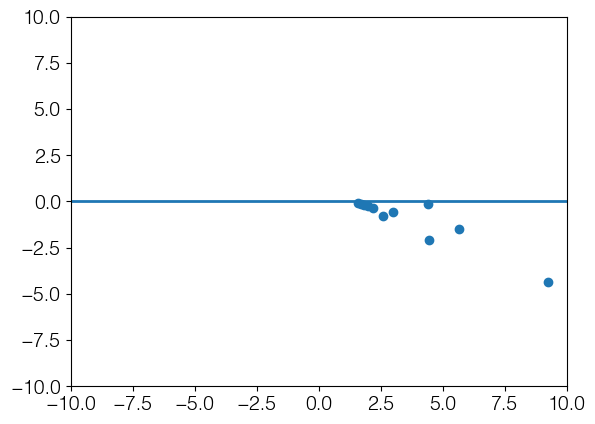

In [298]:
harmonic=1

deg = 20
#nodes = beta_vals
nodes = np.logspace(-2,2,1000)
nodes = np.append(-nodes[::-1],nodes)
aaa= baryrat.aaa(nodes, func, tol=1e-13, mmax=deg, return_errors=False)
aaas[harmonic]=aaa

poles = aaas[harmonic].polres()[0]
print(poles[poles.imag>0])

plt.scatter(poles.real,poles.imag)
l=10
plt.xlim(-l,l)
plt.ylim(-l,l)
plt.axhline(0)
    

### Evaluate the approximation through visual comparison

In [299]:
Sss = []
beta_vals = []
for i,beta_mag in enumerate(beta_magnitudes):
    print(i)
    Ss=[]
    for beta_p in beta_phases:
        beta = beta_mag*np.exp(1j*beta_p)
        Ss.append( eval_AAA(aaa,beta) )
    Sss.append(Ss)
signals_aaa = np.array(Sss)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


Ground truth maximum value: 38.598598935017286
Approximation maximum value: 38.59564477581351
Difference maximum value: 0.03131567853740425


Text(0.5, 1.0, 'Difference')

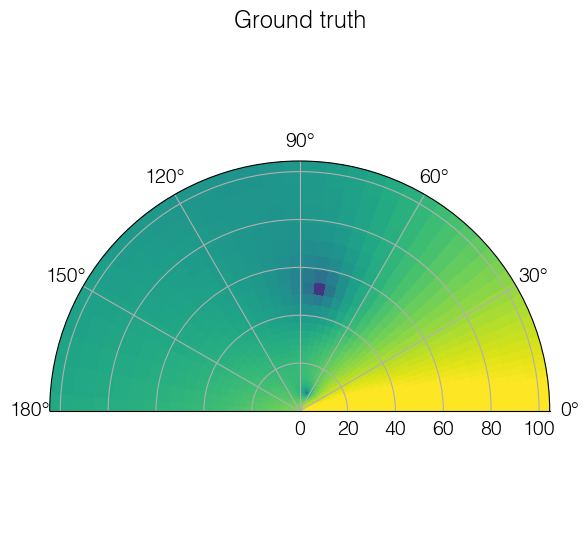

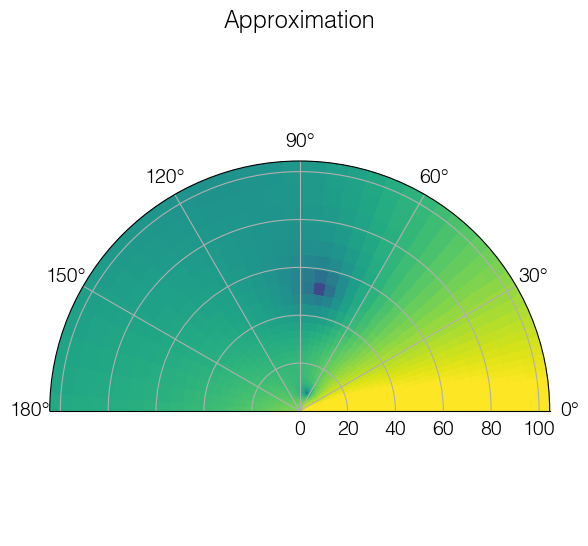

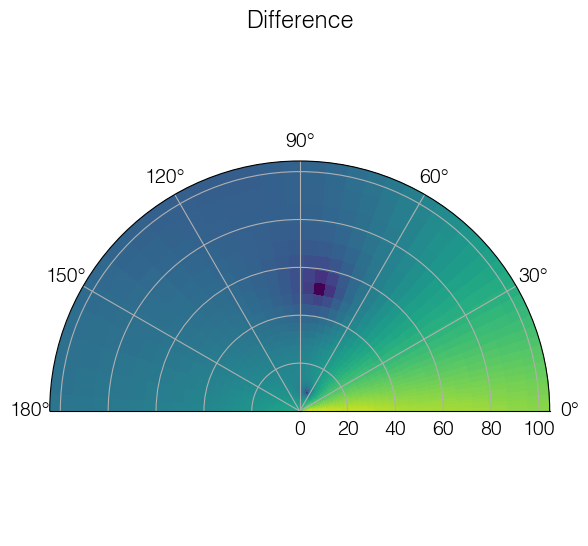

In [300]:
#--- Ground truth
z=np.abs(np.array(signals_IE))[:,:,harmonic]

print('Ground truth maximum value:',z.max())
z=np.log(z)

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Ground truth')

#--- Approximation
z=np.abs(np.array(signals_aaa))

print('Approximation maximum value:',z.max())
z=np.log(z)

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Approximation')


#--- Difference
dz=np.abs(np.array(signals_aaa-signals_IE[:,:,harmonic]))

print('Difference maximum value:',dz.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
#im.set_clim(-6,2)
plt.title('Difference')


### Evaluate the approximation through spectrum

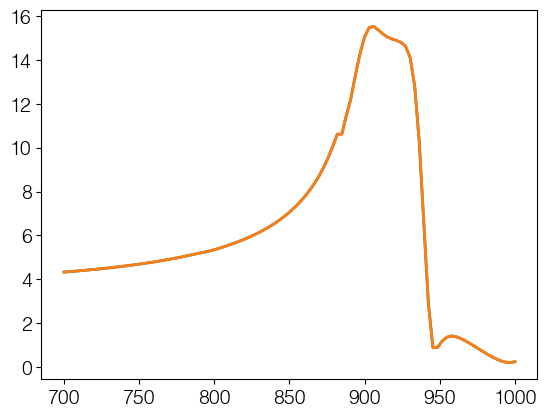

In [301]:
freqs = np.linspace(700,1000,100)
beta_vals = M.SiC_6H.reflection_p(freqs,q=1/20e-7)

spectrum_IE = func(beta_vals)
plt.plot(freqs,np.abs(spectrum_IE))


spectrum_aaa = eval_AAA(aaa,beta_vals)
plt.plot(freqs,np.abs(spectrum_aaa))

## harmonic $n=2$ Rational approximation

[]


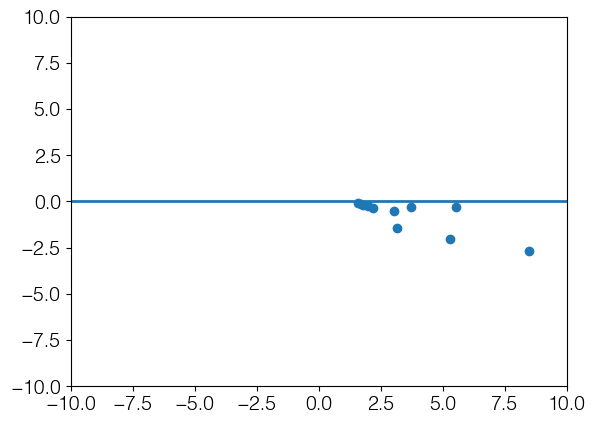

In [302]:
harmonic=2

deg = 20
#nodes = beta_vals
nodes = np.logspace(-2,2,1000)
nodes = np.append(-nodes[::-1],nodes)
aaa= baryrat.aaa(nodes, func, tol=1e-13, mmax=deg, return_errors=False)
aaas[harmonic]=aaa

poles = aaas[harmonic].polres()[0]
print(poles[poles.imag>0])

plt.scatter(poles.real,poles.imag)
l=10
plt.xlim(-l,l)
plt.ylim(-l,l)
plt.axhline(0)
    

### Evaluate the approximation through visual comparison

In [303]:
Sss = []
beta_vals = []
for i,beta_mag in enumerate(beta_magnitudes):
    print(i)
    Ss=[]
    for beta_p in beta_phases:
        beta = beta_mag*np.exp(1j*beta_p)
        Ss.append( eval_AAA(aaa,beta) )
    Sss.append(Ss)
signals_aaa = np.array(Sss)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


Ground truth maximum value: 3.447979272473617
Approximation maximum value: 3.4480451746055105
Difference maximum value: 0.01879857983131214


Text(0.5, 1.0, 'Difference')

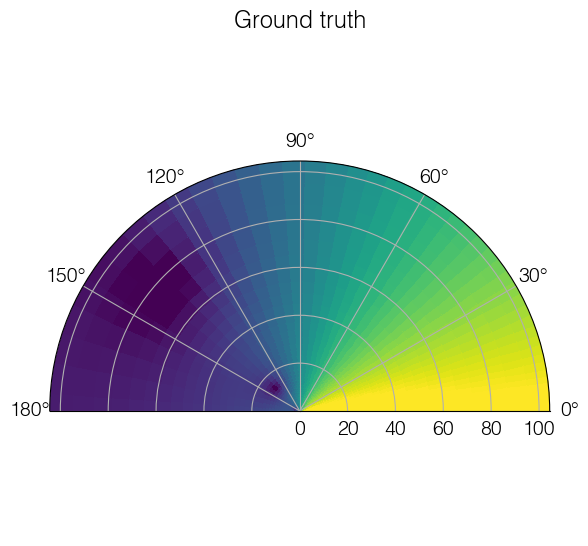

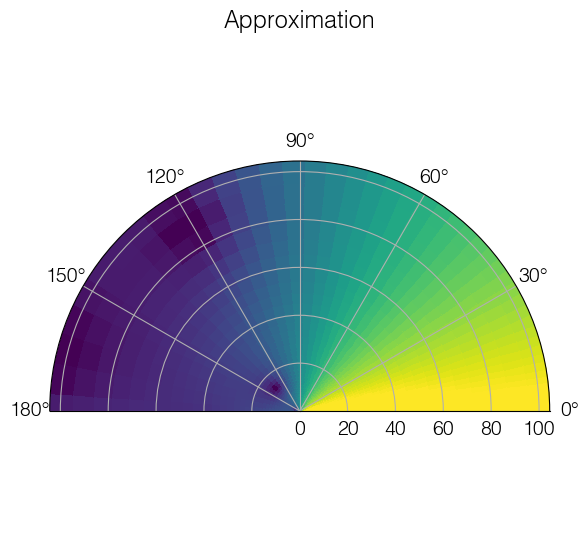

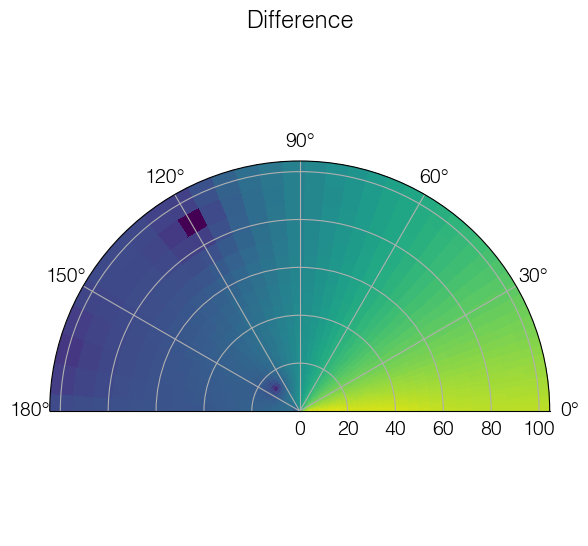

In [304]:
#--- Ground truth
z=np.abs(np.array(signals_IE))[:,:,harmonic]

z=np.log(z)
print('Ground truth maximum value:',z.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Ground truth')

#--- Approximation
z=np.abs(np.array(signals_aaa))

z=np.log(z)
print('Approximation maximum value:',z.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Approximation')


#--- Difference
dz=np.abs(np.array(signals_aaa-signals_IE[:,:,harmonic]))

print('Difference maximum value:',dz.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
#im.set_clim(-6,2)
plt.title('Difference')


### Evaluate the approximation through spectrum

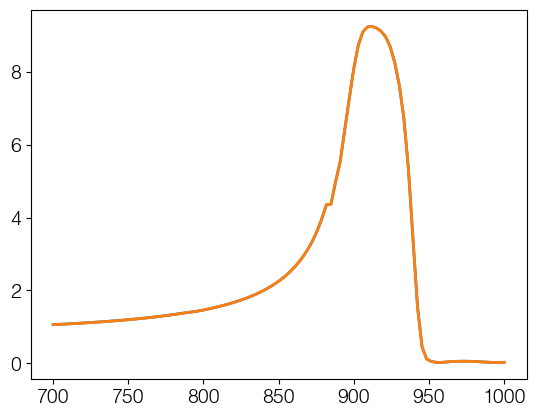

In [305]:
freqs = np.linspace(700,1000,100)
beta_vals = M.SiC_6H.reflection_p(freqs,q=1/20e-7)

spectrum_IE = func(beta_vals)
plt.plot(freqs,np.abs(spectrum_IE))


spectrum_aaa = aaa(beta_vals)
plt.plot(freqs,np.abs(spectrum_aaa))

## harmonic $n=3$ Rational approximation

[]


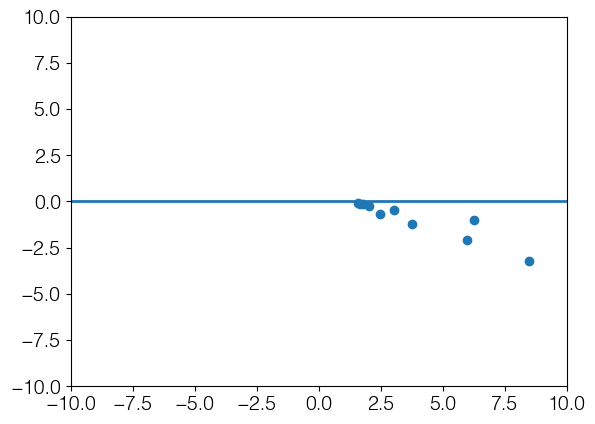

In [306]:
harmonic=3

deg = 20
#nodes = beta_vals
nodes = np.logspace(-2,2,1000)
nodes = np.append(-nodes[::-1],nodes)
aaa= baryrat.aaa(nodes, func, tol=1e-13, mmax=deg, return_errors=False)
aaas[harmonic]=aaa

poles = aaas[harmonic].polres()[0]
print(poles[poles.imag>0])

plt.scatter(poles.real,poles.imag)
l=10
plt.xlim(-l,l)
plt.ylim(-l,l)
plt.axhline(0)
    

### Evaluate the approximation through visual comparison

In [307]:
Sss = []
beta_vals = []
for i,beta_mag in enumerate(beta_magnitudes):
    print(i)
    Ss=[]
    for beta_p in beta_phases:
        beta = beta_mag*np.exp(1j*beta_p)
        Ss.append( aaa(beta) )
    Sss.append(Ss)
signals_aaa = np.array(Sss)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


Ground truth maximum value: 3.1802333944334453
Approximation maximum value: 3.1802322183314287
Difference maximum value: 0.012246480658107697


Text(0.5, 1.0, 'Difference')

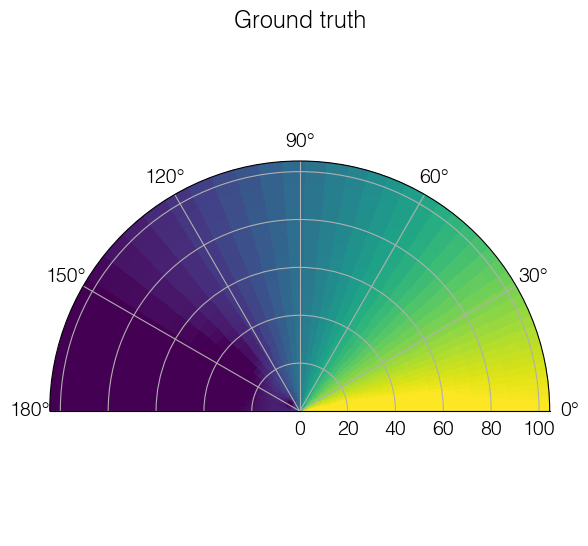

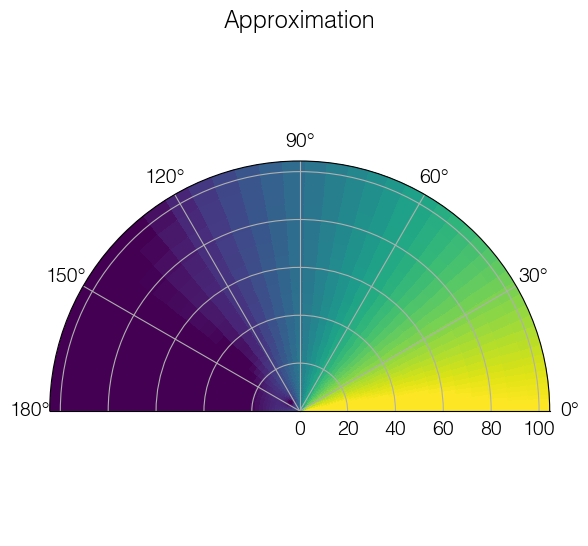

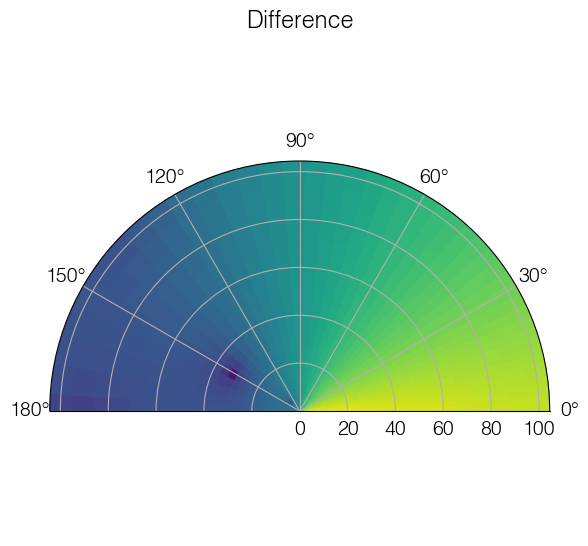

In [308]:
#--- Ground truth
z=np.abs(np.array(signals_IE))[:,:,harmonic]

z=np.log(z)
print('Ground truth maximum value:',z.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Ground truth')

#--- Approximation
z=np.abs(np.array(signals_aaa))

z=np.log(z)
print('Approximation maximum value:',z.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Approximation')


#--- Difference
dz=np.abs(np.array(signals_aaa-signals_IE[:,:,harmonic]))

print('Difference maximum value:',dz.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
#im.set_clim(-6,2)
plt.title('Difference')


### Evaluate the approximation through spectrum

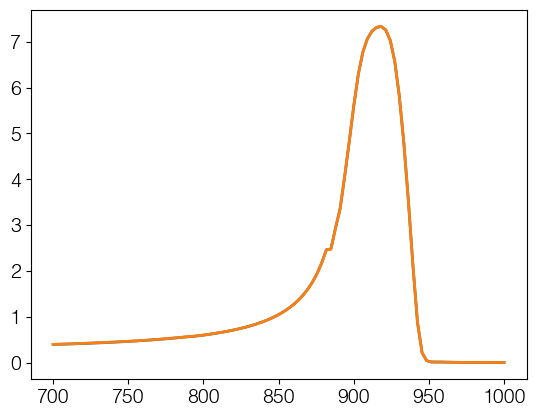

In [309]:
freqs = np.linspace(700,1000,100)
beta_vals = M.SiC_6H.reflection_p(freqs,q=1/20e-7)

spectrum_IE = func(beta_vals)
plt.plot(freqs,np.abs(spectrum_IE))


spectrum_aaa = aaa(beta_vals)
plt.plot(freqs,np.abs(spectrum_aaa))

## harmonic $n=4$ Rational approximation

[]


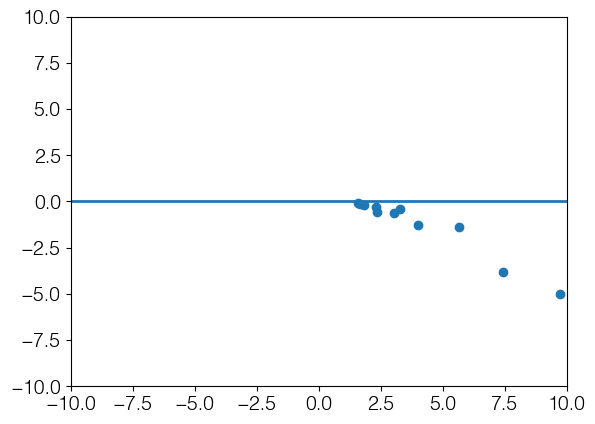

In [310]:
harmonic=4

deg = 20
#nodes = beta_vals
nodes = np.logspace(-2,2,1000)
nodes = np.append(-nodes[::-1],nodes)
aaa= baryrat.aaa(nodes, func, tol=1e-13, mmax=deg, return_errors=False)
aaas[harmonic]=aaa

poles = aaas[harmonic].polres()[0]
print(poles[poles.imag>0])

plt.scatter(poles.real,poles.imag)
l=10
plt.xlim(-l,l)
plt.ylim(-l,l)
plt.axhline(0)
    

### Evaluate the approximation through visual comparison

In [311]:
Sss = []
beta_vals = []
for i,beta_mag in enumerate(beta_magnitudes):
    print(i)
    Ss=[]
    for beta_p in beta_phases:
        beta = beta_mag*np.exp(1j*beta_p)
        Ss.append( aaa(beta) )
    Sss.append(Ss)
signals_aaa = np.array(Sss)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


Ground truth maximum value: 3.0627905969311686
Approximation maximum value: 3.062812132742298
Difference maximum value: 0.009116383512546122


Text(0.5, 1.0, 'Difference')

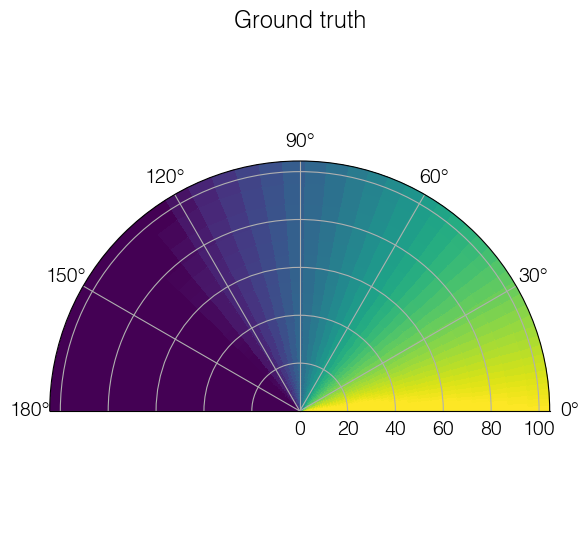

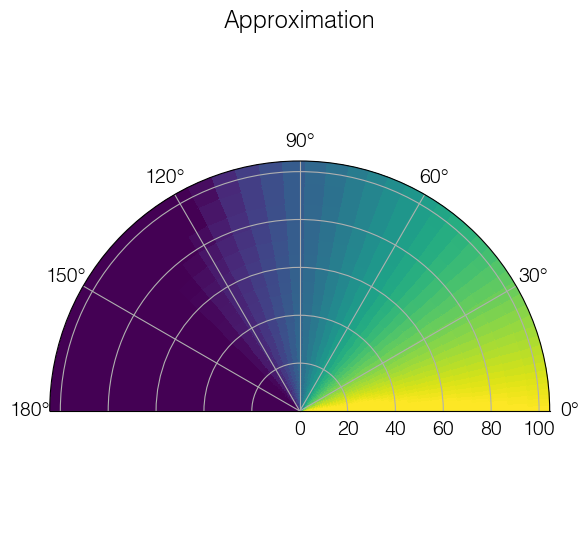

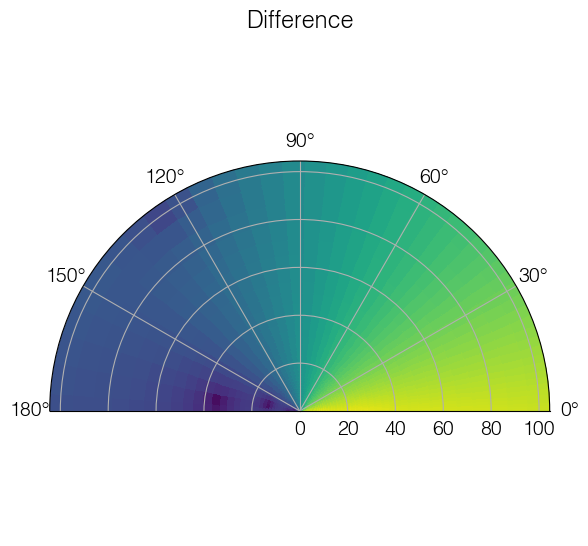

In [312]:
#--- Ground truth
z=np.abs(np.array(signals_IE))[:,:,harmonic]

z=np.log(z)
print('Ground truth maximum value:',z.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Ground truth')

#--- Approximation
z=np.abs(np.array(signals_aaa))

z=np.log(z)
print('Approximation maximum value:',z.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
im.set_clim(-6,2)
plt.title('Approximation')


#--- Difference
dz=np.abs(np.array(signals_aaa-signals_IE[:,:,harmonic]))

print('Difference maximum value:',dz.max())

fig = plt.figure(figsize=[5,5])
ax = fig.add_axes([0,0,1,1],polar=True)
im=ax.pcolormesh(beta_phases,beta_magnitudes,z,edgecolors='face')
ax.set_thetamin(0)
ax.set_thetamax(180)
#im.set_clim(-6,2)
plt.title('Difference')


### Evaluate the approximation through spectrum

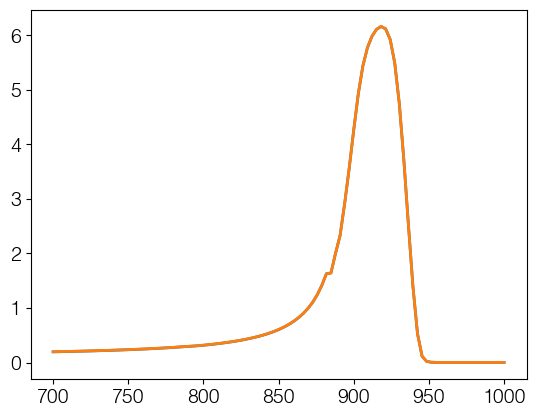

In [313]:
freqs = np.linspace(700,1000,100)
beta_vals = M.SiC_6H.reflection_p(freqs,q=1/20e-7)

spectrum_IE = func(beta_vals)
plt.plot(freqs,np.abs(spectrum_IE))


spectrum_aaa = aaa(beta_vals)
plt.plot(freqs,np.abs(spectrum_aaa))

# Print all poles and residues for each harmonic

In [314]:
harmonics = [1,2,3,4]
gains = [aaas[harmonic].gain() for harmonic in harmonics]

poles={}
ress={}
for harmonic in harmonics:
    p,r = aaas[harmonic].polres()
    poles[harmonic]=p
    ress[harmonic]=r

In [315]:
fmt='%1.6G'
gains_real_line = ' & '.join( (fmt%g.real for g in gains) )
gains_imag_line = ' & '.join( (fmt%g.imag for g in gains) )
print( gains_real_line +' & '+gains_imag_line+r' \\')
print()
print('\hline')
for n in range(deg-1):
    poles_line_re = ' & '.join( (fmt%poles[harm][n].real for harm in harmonics) )
    poles_line_im = ' & '.join( (fmt%poles[harm][n].imag for harm in harmonics) )
    print(  poles_line_re + '& '+poles_line_im+r' \\')
print()
print('\hline')
for n in range(deg-1):
    res_line_re = ' & '.join( (fmt%ress[harm][n].real for harm in harmonics) )
    res_line_im = ' & '.join( (fmt%ress[harm][n].imag for harm in harmonics) )
    print(  res_line_re + '& '+res_line_im+r' \\')

0.448489 & 0.242457 & 0.0922582 & 0.0197569 & 0.0428451 & -0.00614525 & -0.0690998 & -0.133243 \\

\hline
152.524 & 166.305 & 178.256 & 177.507& -35.1367 & -37.9905 & -13.0778 & -29.3948 \\
67.6482 & 86.4453 & 106.192 & 54.0939& -25.5817 & -35.0865 & -33.9439 & -80.4892 \\
51.1135 & 64.9383 & 66.9524 & 71.7524& -12.946 & -11.8754 & -23.0408 & -30.6689 \\
36.1831 & 42.3987 & 46.858 & 52.3823& -9.89961 & -12.8257 & -14.3111 & -13.2163 \\
25.7026 & 27.7517 & 37.3031 & 36.4888& -7.16406 & -7.08087 & -0.774079 & -8.99182 \\
21.2019 & 18.8452 & 31.479 & 24.5921& -4.06965 & -5.60464 & -7.27898 & -7.59197 \\
12.217 & 16.6862 & 23.8443 & 23.4136& -9.07917 & -4.80437 & -4.86516 & -1.22909 \\
14.171 & 11.8785 & 21.8089 & 15.1486& -3.62853 & -5.3624 & -6.41319 & -3.51596 \\
9.24369 & 8.49884 & 14.9606 & 9.73346& -4.34623 & -2.68918 & -5.08768 & -5.00486 \\
5.64727 & 5.30453 & 8.4748 & 7.41804& -1.49846 & -2.01253 & -3.24174 & -3.83999 \\
4.45979 & 5.5354 & 5.97618 & 5.64396& -2.09253 & -0.324259 &